# Applying MaxFilter after identifying bad sensors

## Introduction

The aim of this notebook is to demonstrate the application of Maxwell filtering, also called signal-space separation (SSS), to the DAD MEG recordings. This follows the structure of the FLUX MaxFilter notebook, but the paths and file names are adapted to the local non-BIDS DAD data layout.

Maxwell filtering reduces interference from environmental sources and sensor noise by separating the measured MEG signal into components that can be explained by sources inside the sensor array and components that can be explained by sources outside the sensor array. The method also uses site-specific calibration and cross-talk files. These files are specific to the MEG system and should be obtained from the local MEG facility.

Before applying Maxwell filtering it is advisable to identify bad sensors. If a noisy or flat sensor is left unmarked, its artifacts can be distributed to other sensors during the SSS reconstruction.

In this example we process multiple acquisition runs for one participant. We detect bad channels separately in every run, then use the union of all detected bad channels for every run. This is conservative and keeps the channel basis consistent across runs. We do not concatenate runs at this stage; Maxwell filtering is applied independently to each acquisition run.

## Preparation

First load the Python modules. The notebook uses MNE-Python directly, rather than the production DAD pipeline scripts, so that the MaxFilter step is visible and easy to adapt.

In [1]:
from pathlib import Path
try:
    import tomllib
except ModuleNotFoundError:  # for Python < 3.11
    import tomli as tomllib
import numpy as np
import matplotlib.pyplot as plt
import mne

In [5]:
Path(__file__)

NameError: name '__file__' is not defined

Define the shared configuration and build BIDS-style input and output file names. The subject, session, task, and runs are selected in `config.toml`, so the same choices are used by the notebooks and the companion scripts.

In [2]:
# -----------------------------------------------------------------------------
# Load shared configuration
# -----------------------------------------------------------------------------

# The notebooks and scripts read the same config file. Keep root = '.' in
# config.toml when the file stays in the pipeline root, or change it there if
# the dataset is stored somewhere else.
script_dir = Path('__file__').resolve().parent
config_file = Path('config.toml')
if not config_file.exists():
    for parent in Path.cwd().resolve().parents:
        candidate = parent / 'config.toml'
        if candidate.exists():
            config_file = candidate
            break
if not config_file.exists():
    raise FileNotFoundError('Could not find config.toml. Start Jupyter from the pipeline root or edit config_file.')

with config_file.open('rb') as fid:
    config = tomllib.load(fid)

root = Path(config['paths']['root'])
if not root.is_absolute():
    root = (config_file.parent / root).resolve()

subject = str(config['dataset']['subject']).zfill(2)
session = str(config['dataset']['session'])
task = str(config['dataset']['task'])
run_labels = [f'{int(run):02d}' for run in config['dataset']['runs']]

bids_subject = f'sub-{subject}'
bids_session = f'ses-{session}'
bids_prefix = f'{bids_subject}_{bids_session}_task-{task}'

raw_dir = root / bids_subject / bids_session / 'meg'
deriv_root = root / config['paths']['derivatives']
deriv_dir = deriv_root / bids_subject / bids_session / 'meg'
report_dir = deriv_root / bids_subject / bids_session / "reports"

deriv_dir.mkdir(parents=True, exist_ok=True)
report_dir.mkdir(parents=True, exist_ok=True)

report_file = report_dir / "01_maxfilter.html"
report = mne.Report(title=f"01 MaxFilter - {bids_subject} {bids_session}")

raw_files = [
    raw_dir / f'{bids_prefix}_run-{run}_meg.fif'
    for run in run_labels
]
missing_raw_files = [path for path in raw_files if not path.is_file()]
if missing_raw_files:
    missing = "\n  ".join(str(path) for path in missing_raw_files)
    raise FileNotFoundError(f'Missing configured raw FIF files:\n {missing}')

sss_files = {
    raw_file: deriv_dir / f'{bids_prefix}_run-{run}_desc-maxfilter_meg.fif'
    for raw_file, run in zip(raw_files, run_labels, strict=True)
}

print("Config file:")
print("  ", config_file)
print("Pipeline root:")
print("  ", root)
print("Subject/session/task/runs:")
print("  ", bids_subject, bids_session, task, run_labels)

print("Raw files:")
for raw_file in raw_files:
    print("  ", raw_file)

print("\nOutput files:")
for raw_file, sss_file in sss_files.items():
    print("  ", sss_file)

print("\nReport file:")
print("  ", report_file)


Embedding : jquery-3.6.0.min.js
Embedding : bootstrap.bundle.min.js
Embedding : bootstrap.min.css
Embedding : bootstrap-table/bootstrap-table.min.js
Embedding : bootstrap-table/bootstrap-table.min.css
Embedding : bootstrap-table/bootstrap-table-copy-rows.min.js
Embedding : bootstrap-table/bootstrap-table-export.min.js
Embedding : bootstrap-table/tableExport.min.js
Embedding : bootstrap-icons/bootstrap-icons.mne.min.css
Embedding : highlightjs/highlight.min.js
Embedding : highlightjs/atom-one-dark-reasonable.min.css
Config file:
   /Users/goal0312/Desktop/thesis/data/config.toml
Pipeline root:
   /Users/goal0312/Desktop/thesis/data
Subject/session/task/runs:
   sub-01 ses-01 IceSkating ['01']
Raw files:
   /Users/goal0312/Desktop/thesis/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-01_meg.fif

Output files:
   /Users/goal0312/Desktop/thesis/data/derivatives/mne-preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-01_desc-maxfilter_meg.fif

Report file:
   /Users/

Now define the BIDS-style calibration and cross-talk files for this subject and session. These are relative symlinks to the site files preserved under `sourcedata/fwmegmaxfilter`.

In [3]:
crosstalk_file = raw_dir / f'{bids_subject}_{bids_session}_acq-crosstalk_meg.fif'
calibration_file = raw_dir / f'{bids_subject}_{bids_session}_acq-calibration_meg.dat'

if not crosstalk_file.is_file():
    raise FileNotFoundError(crosstalk_file)
if not calibration_file.is_file():
    raise FileNotFoundError(calibration_file)

print(crosstalk_file)
print(calibration_file)

/Users/goal0312/Desktop/thesis/data/sub-01/ses-01/meg/sub-01_ses-01_acq-crosstalk_meg.fif
/Users/goal0312/Desktop/thesis/data/sub-01/ses-01/meg/sub-01_ses-01_acq-calibration_meg.dat


Read the raw data.

We read all acquisition runs into memory because both bad-channel detection and Maxwell filtering need access to the signal. For larger datasets or memory-limited machines, run this notebook subject by subject and avoid keeping unnecessary copies alive.

In [4]:
raws = {}
for raw_file in raw_files:
    print(f'\nReading {raw_file.name}')
    raws[raw_file] = mne.io.read_raw_fif(raw_file, preload=True, verbose=True)

print('\nLoaded runs:')
for raw_file, raw in raws.items():
    print(f'{raw_file.name}: {raw.info["nchan"]} channels, {raw.n_times} samples, sfreq={raw.info["sfreq"]}')


Reading sub-01_ses-01_task-IceSkating_run-01_meg.fif
Opening raw data file /Users/goal0312/Desktop/thesis/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-01_meg.fif...
    Read a total of 10 projection items:
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
    Range : 20000 ... 751999 =     20.000 ...   751.999 secs
Ready.
Reading 0 ... 731999  =      0.000 ...   731.999 secs...

Loaded runs:
sub-01_ses-01_task-IceSkating_run-01_meg.fif: 326 channels, 732000 samples, sfreq=1000.0


In [ ]:
raws[raw_files[0]].

<Raw | sub-01_ses-01_task-IceSkating_run-01_meg.fif, 326 x 732000 (732.0 s), ~1.78 GiB, data loaded>

Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).


/Users/goal0312/anaconda3/envs/skating/lib/python3.11/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


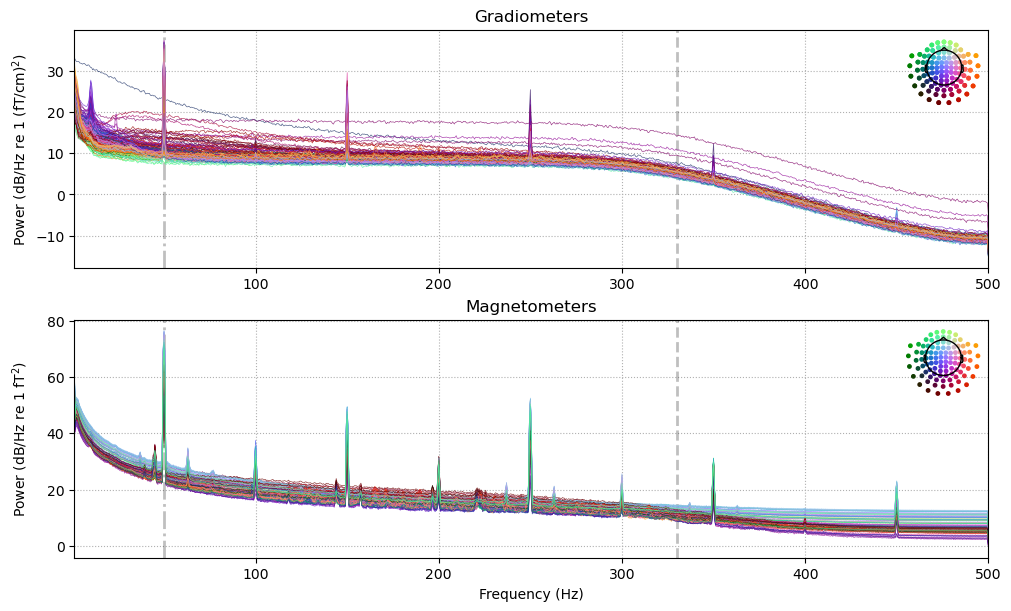

In [6]:
n_fft = 2000
temp_psd = raws[raw_files[0]].compute_psd(
        method='welch',
        fmin=1,
        fmax=500,
        n_fft=min(n_fft, raws[raw_files[0]].n_times),
        n_overlap=min(int(n_fft / 2), max(raws[raw_files[0]].n_times - 1, 0)),
    )
%matplotlib inline  
temp_psd.plot();

In [ ]:
raws[raw_files[0]].plot()

<mne_qt_browser._pg_figure.MNEQtBrowser(0x7f811ad7e400) at 0x181b2fe40>

qt.pointer.dispatch: skipping QEventPoint(id=0 ts=0 pos=0,0 scn=725.546,315.755 gbl=725.546,315.755 Released ellipse=(1x1 ∡ 0) vel=0,0 press=-725.546,-315.755 last=-725.546,-315.755 Δ 725.546,315.755) : no target window
qt.pointer.dispatch: skipping QEventPoint(id=1 ts=0 pos=0,0 scn=881.964,340.777 gbl=881.964,340.777 Released ellipse=(1x1 ∡ 0) vel=0,0 press=-881.964,-340.777 last=-881.964,-340.777 Δ 881.964,340.777) : no target window
qt.pointer.dispatch: skipping QEventPoint(id=1 ts=0 pos=0,0 scn=755.747,319.929 gbl=755.747,319.929 Released ellipse=(1x1 ∡ 0) vel=0,0 press=-755.747,-319.929 last=-755.747,-319.929 Δ 755.747,319.929) : no target window
qt.pointer.dispatch: skipping QEventPoint(id=1 ts=0 pos=0,0 scn=915.493,331.034 gbl=915.493,331.034 Released ellipse=(1x1 ∡ 0) vel=0,0 press=-915.493,-331.034 last=-915.493,-331.034 Δ 915.493,331.034) : no target window
qt.pointer.dispatch: skipping QEventPoint(id=1 ts=0 pos=0,0 scn=284.881,276.456 gbl=284.881,276.456 Released ellipse=(1x

### Identify the faulty sensors

The following code identifies noisy and flat sensors using `mne.preprocessing.find_bad_channels_maxwell`.

In the original FLUX notebook this is demonstrated for one run and then applied to the second run. Here we have five DAD acquisition runs. We therefore detect bad channels independently for every run and then form the union across runs.

**Question 1:** Should bad channels be assessed from only one run or from all runs?

**Answer:** For a multi-run experiment, assess all runs. A sensor can become noisy only in later runs, and one run can also contain a transient artifact that is not representative of the whole recording. Looking at every run gives a better overview of the subject-level sensor quality.

**Question 2:** Why use the union of bad channels across runs?

**Answer:** The union is conservative and keeps the set of usable channels consistent across acquisition runs. This matters because later ICA and epoch-level analyses assume comparable channel information across runs. A per-run bad-channel policy is possible, but it creates a changing channel basis that must be handled carefully downstream. NB: check the number of channels discarded, if too high, check the data and change strategy (e.g. intersection set).

In [15]:
raws

{PosixPath('/Users/goal0312/Desktop/thesis/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-01_meg.fif'): <Raw | sub-01_ses-01_task-IceSkating_run-01_meg.fif, 326 x 732000 (732.0 s), ~1.78 GiB, data loaded>,
 PosixPath('/Users/goal0312/Desktop/thesis/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-02_meg.fif'): <Raw | sub-01_ses-01_task-IceSkating_run-02_meg.fif, 326 x 636000 (636.0 s), ~1.55 GiB, data loaded>,
 PosixPath('/Users/goal0312/Desktop/thesis/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-03_meg.fif'): <Raw | sub-01_ses-01_task-IceSkating_run-03_meg.fif, 326 x 655000 (655.0 s), ~1.60 GiB, data loaded>,
 PosixPath('/Users/goal0312/Desktop/thesis/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-04_meg.fif'): <Raw | sub-01_ses-01_task-IceSkating_run-04_meg.fif, 326 x 647000 (647.0 s), ~1.58 GiB, data loaded>,
 PosixPath('/Users/goal0312/Desktop/thesis/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-05_meg.fif'): <Raw | sub-01_ses-01_t

In [16]:
list(raws.items())[0]

(PosixPath('/Users/goal0312/Desktop/thesis/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-01_meg.fif'),
 <Raw | sub-01_ses-01_task-IceSkating_run-01_meg.fif, 326 x 732000 (732.0 s), ~1.78 GiB, data loaded>)

In [72]:
raw_file, raw = list(raws.items())[1]

In [73]:
raw_file,raw

(PosixPath('/Users/goal0312/Desktop/thesis/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-02_meg.fif'),
 <Raw | sub-01_ses-01_task-IceSkating_run-02_meg.fif, 326 x 636000 (636.0 s), ~1.55 GiB, data loaded>)

In [ ]:
raw.info.keys()

# fif gives us attributes: 
# dict_keys(['file_id', 'events', 'hpi_results', 'hpi_meas', 'subject_info', 
# 'device_info', 'helium_info', 'hpi_subsystem', 'proc_history', 'meas_id', 'experimenter',
# 'description', 'proj_id', 'proj_name', 'meas_date', 'utc_offset', 'sfreq', 'highpass', 'lowpass',
# 'line_freq', 'gantry_angle', 'chs', 'dev_head_t', 'ctf_head_t', 'dev_ctf_t', 'dig', 'bads', 
# 'ch_names', 'nchan', 'projs', 'comps', 'acq_pars', 'acq_stim', 'custom_ref_applied', 'xplotter_layout', 'kit_system_id'])

# methods: raw.get_data(), raw.filter(...), raw.pick(...), raw.crop(...), raw.save(...), raw.compute_psd(...), raw.plot(...), raw.copy()
# methods are grouped into channel selection/editing: eg .pick(example_bad_channels)
# processing/filtering
# annotation/bads
# analysis: compute_psd, get_montage
# visualization: plot
# i/o
# these modify in place, so if we dont want to modify the original results -> .copy() first
raw.get_data

<bound method get_data of <Raw | sub-01_ses-01_task-IceSkating_run-02_meg.fif, 326 x 636000 (636.0 s), ~1.55 GiB, data loaded>>

In [34]:
raw.info['bads']

[]

In [6]:
# -----------------------------------------------------------------------------
# Automatic bad-channel detection per run
# -----------------------------------------------------------------------------

detected_bads = {}
for raw_file, raw in raws.items(): # raw_file (path) is key and raw (metadata) is value
    print(f'\nDetecting bad channels in {raw_file.name}')
    raw_for_detection = raw.copy()
    raw_for_detection.info['bads'] = []

    auto_noisy_chs, auto_flat_chs, auto_scores = mne.preprocessing.find_bad_channels_maxwell(
        raw_for_detection,
        cross_talk=str(crosstalk_file),
        calibration=str(calibration_file),
        return_scores=True,
        verbose=True,
    )
# noisy_chs: list of MEG channels flagged noisy
# flat_chs: list of MEG channels flagged flat (std < 0.01 fT or fT/cm over a 30 ms window)
# scores: ch_names, ch_types, bins, scores_flat, limits_flat, scores_noisy, limits_noisy
    detected_bads[raw_file] = {
        'noisy': list(auto_noisy_chs),
        'flat': list(auto_flat_chs),
    }

    print('noisy =', auto_noisy_chs)
    print('flat  =', auto_flat_chs)

union_bad_channels = sorted({
    ch
    for run_bads in detected_bads.values()
    for ch in (run_bads['noisy'] + run_bads['flat'])
})

print('\nUnion of bad channels across all runs:')
print(union_bad_channels)


Detecting bad channels in sub-01_ses-01_task-IceSkating_run-01_meg.fif


KeyboardInterrupt: 

In [9]:
import pickle,os
path = '/Users/goal0312/Desktop/thesis/data'
with open(os.path.join(path, 'detected_bads.pkl'), 'rb') as f:
    detected_bads = pickle.load(f)

In [8]:
detected_bads

{PosixPath('/mnt/storage/tier2/ingdev/projects/THANH/IceSkating/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-01_meg.fif'): {'noisy': ['MEG0622',
   'MEG0642',
   'MEG1032',
   'MEG1642',
   'MEG1741'],
  'flat': []},
 PosixPath('/mnt/storage/tier2/ingdev/projects/THANH/IceSkating/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-02_meg.fif'): {'noisy': ['MEG0622',
   'MEG0642',
   'MEG1012',
   'MEG1032',
   'MEG1642',
   'MEG1741'],
  'flat': []},
 PosixPath('/mnt/storage/tier2/ingdev/projects/THANH/IceSkating/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-03_meg.fif'): {'noisy': ['MEG0622',
   'MEG0642',
   'MEG1012',
   'MEG1032',
   'MEG1642',
   'MEG1741'],
  'flat': []},
 PosixPath('/mnt/storage/tier2/ingdev/projects/THANH/IceSkating/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-04_meg.fif'): {'noisy': ['MEG0622',
   'MEG0642',
   'MEG1032',
   'MEG1642',
   'MEG1741'],
  'flat': []},
 PosixPath('/mnt/storage/tier2/ingdev/projects/THANH/Ice

Show the sensors that were detected as noisy and flat.

This summary table is the first decision record for the MaxFilter step. If a channel looks suspicious in the automatic output, inspect the time series and spectra below before accepting it as bad.

In [10]:

union_bad_channels = sorted({
    ch
    for run_bads in detected_bads.values()
    for ch in (run_bads["noisy"] + run_bads["flat"])
})

In [15]:
union_bad_channels

['MEG0622', 'MEG0642', 'MEG1012', 'MEG1032', 'MEG1642', 'MEG1741', 'MEG2112']

Plot the time course of a few automatically detected bad sensors.

If no bad sensors were detected, the cell prints a message and does not open the browser.

In [ ]:
example_bad_channels = union_bad_channels[:4]
first_raw_file = raw_files[0]

if example_bad_channels:
    raw_bad_preview = raws[first_raw_file].copy().pick(example_bad_channels)
    raw_bad_preview.plot(proj=False)
else:
    print('No automatic bad channels were detected, so there are no bad-channel traces to plot.')

Using qt as 2D backend.


shibokensupport/signature/parser.py:270: RuntimeWarning: pyside_type_init:_resolve_value

        UNRECOGNIZED:   'PySide6.QtWidgets.QWidget'
        OFFENDING LINE: '1:PySide6.QtWidgets.QFileDialog(self,parent:PySide6.QtWidgets.QWidget,f:PySide6.QtCore.Qt.WindowType)'
        
shibokensupport/signature/parser.py:270: RuntimeWarning: pyside_type_init:_resolve_value

        UNRECOGNIZED:   'PySide6.QtCore.Qt.WindowType'
        OFFENDING LINE: '1:PySide6.QtWidgets.QFileDialog(self,parent:PySide6.QtWidgets.QWidget,f:PySide6.QtCore.Qt.WindowType)'
        
shibokensupport/signature/parser.py:270: RuntimeWarning: pyside_type_init:_resolve_value

        UNRECOGNIZED:   'PySide6.QtWidgets.QWidget'
        OFFENDING LINE: '0:PySide6.QtWidgets.QFileDialog(self,parent:PySide6.QtWidgets.QWidget=nullptr,caption:QString=QString(),directory:QString=QString(),filter:QString=QString())'
        
shibokensupport/signature/parser.py:270: RuntimeWarning: pyside_type_init:_resolve_value

        UNRECO

Channels marked as bad:
none


2026-07-20 14:24:28.856 python[4972:3772512] _TIPropertyValueIsValid called with 4 on nil context!
2026-07-20 14:24:28.857 python[4972:3772512] imkxpc_getApplicationProperty:reply: called with incorrect property value 4, bailing.
2026-07-20 14:24:28.857 python[4972:3772512] Text input context does not respond to _valueForTIProperty:


Channels marked as bad:
none


Example for plotting power spectra of the same sensors.

**Question 3:** What might be causing the noisy sensors, and could something be done to reduce the problem for future acquisitions?

**Answer:** Possible causes include sensor instability, environmental interference, participant movement, dental or metallic artifacts, or a transient system issue. If the same channels are repeatedly noisy across participants, this should be reported to the MEG facility. If the noise is participant-specific, check positioning, movement, and any metal or electronic devices before future recordings.

In [17]:
example_bad_channels

['MEG0622', 'MEG0642', 'MEG1012', 'MEG1032']

In [18]:
raw_bad_preview

<Raw | sub-01_ses-01_task-IceSkating_run-01_meg.fif, 4 x 732000 (732.0 s), ~29.0 MiB, data loaded>

Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).


/Users/goal0312/anaconda3/envs/skating/lib/python3.11/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


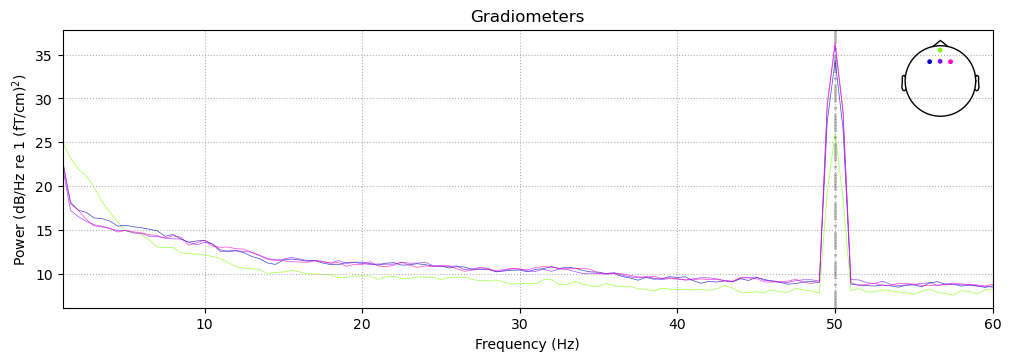

In [9]:
if example_bad_channels:
    n_fft = 2000
    temp_psd = raw_bad_preview.compute_psd(
        method='welch',
        fmin=1,
        fmax=60,
        n_fft=min(n_fft, raw_bad_preview.n_times),
        n_overlap=min(int(n_fft / 2), max(raw_bad_preview.n_times - 1, 0)),
    )
    %matplotlib inline  
    temp_psd.plot();
else:
    print('No automatic bad channels were detected, so there are no bad-channel spectra to plot.')

Set the union of noisy and flat sensors as bad in every run.

The DAD files may already contain bad-channel labels in their headers. Here we explicitly replace the bad-channel list with the union derived above, so the decision is clear and reproducible for this tutorial. In a real analysis, manually reviewed additions or removals should be recorded here.

In [10]:
for raw_file, raw in raws.items():
    raw.info['bads'] = list(union_bad_channels)
    print(raw_file.name, 'bads =', raw.info['bads'])

sub-01_ses-01_task-IceSkating_run-01_meg.fif bads = ['MEG0622', 'MEG0642', 'MEG1012', 'MEG1032', 'MEG1642', 'MEG1741', 'MEG2112']
sub-01_ses-01_task-IceSkating_run-02_meg.fif bads = ['MEG0622', 'MEG0642', 'MEG1012', 'MEG1032', 'MEG1642', 'MEG1741', 'MEG2112']
sub-01_ses-01_task-IceSkating_run-03_meg.fif bads = ['MEG0622', 'MEG0642', 'MEG1012', 'MEG1032', 'MEG1642', 'MEG1741', 'MEG2112']
sub-01_ses-01_task-IceSkating_run-04_meg.fif bads = ['MEG0622', 'MEG0642', 'MEG1012', 'MEG1032', 'MEG1642', 'MEG1741', 'MEG2112']
sub-01_ses-01_task-IceSkating_run-05_meg.fif bads = ['MEG0622', 'MEG0642', 'MEG1012', 'MEG1032', 'MEG1642', 'MEG1741', 'MEG2112']
sub-01_ses-01_task-IceSkating_run-06_meg.fif bads = ['MEG0622', 'MEG0642', 'MEG1012', 'MEG1032', 'MEG1642', 'MEG1741', 'MEG2112']


Change MEGIN magnetometer coil types where needed.

This follows the FLUX recommendation to make magnetometer coil definitions compatible across MEGIN systems before applying Maxwell filtering.

In [13]:
# MEGIN systems store a coil_type for every channel
for i in range(raw.info['nchan']):
    print(raw.info["chs"][i]["coil_type"]) # channel 1 coil type

0 (FIFFV_COIL_NONE)
0 (FIFFV_COIL_NONE)
0 (FIFFV_COIL_NONE)
0 (FIFFV_COIL_NONE)
0 (FIFFV_COIL_NONE)
0 (FIFFV_COIL_NONE)
0 (FIFFV_COIL_NONE)
0 (FIFFV_COIL_NONE)
0 (FIFFV_COIL_NONE)
0 (FIFFV_COIL_NONE)
0 (FIFFV_COIL_NONE)
3022 (FIFFV_COIL_VV_MAG_T1)
3012 (FIFFV_COIL_VV_PLANAR_T1)
3012 (FIFFV_COIL_VV_PLANAR_T1)
3022 (FIFFV_COIL_VV_MAG_T1)
3012 (FIFFV_COIL_VV_PLANAR_T1)
3012 (FIFFV_COIL_VV_PLANAR_T1)
3022 (FIFFV_COIL_VV_MAG_T1)
3012 (FIFFV_COIL_VV_PLANAR_T1)
3012 (FIFFV_COIL_VV_PLANAR_T1)
3022 (FIFFV_COIL_VV_MAG_T1)
3012 (FIFFV_COIL_VV_PLANAR_T1)
3012 (FIFFV_COIL_VV_PLANAR_T1)
3022 (FIFFV_COIL_VV_MAG_T1)
3012 (FIFFV_COIL_VV_PLANAR_T1)
3012 (FIFFV_COIL_VV_PLANAR_T1)
3022 (FIFFV_COIL_VV_MAG_T1)
3012 (FIFFV_COIL_VV_PLANAR_T1)
3012 (FIFFV_COIL_VV_PLANAR_T1)
3022 (FIFFV_COIL_VV_MAG_T1)
3012 (FIFFV_COIL_VV_PLANAR_T1)
3012 (FIFFV_COIL_VV_PLANAR_T1)
3022 (FIFFV_COIL_VV_MAG_T1)
3012 (FIFFV_COIL_VV_PLANAR_T1)
3012 (FIFFV_COIL_VV_PLANAR_T1)
3022 (FIFFV_COIL_VV_MAG_T1)
3012 (FIFFV_COIL_VV_PLANAR_T1)
3

In [7]:
# any magnetometer channel whose coil_type is currently 3022 (T1) or 3023 (T2)
# gets its coil_type value overwritten to 3024 (T3) in raw.info["chs"]
for raw_file, raw in raws.items():
    raw.fix_mag_coil_types()
    print(f'Checked magnetometer coil types for {raw_file.name}')

102 of 102 magnetometer types replaced with T3.
Checked magnetometer coil types for sub-01_ses-01_task-IceSkating_run-01_meg.fif
102 of 102 magnetometer types replaced with T3.
Checked magnetometer coil types for sub-01_ses-01_task-IceSkating_run-02_meg.fif
102 of 102 magnetometer types replaced with T3.
Checked magnetometer coil types for sub-01_ses-01_task-IceSkating_run-03_meg.fif
102 of 102 magnetometer types replaced with T3.
Checked magnetometer coil types for sub-01_ses-01_task-IceSkating_run-04_meg.fif
102 of 102 magnetometer types replaced with T3.
Checked magnetometer coil types for sub-01_ses-01_task-IceSkating_run-05_meg.fif
102 of 102 magnetometer types replaced with T3.
Checked magnetometer coil types for sub-01_ses-01_task-IceSkating_run-06_meg.fif


In [93]:
raws[raw_files[3]].info['chs'][11]['coil_type']

3024 (FIFFV_COIL_VV_MAG_T3)

In [95]:
from mne.io.constants import FIFF
len([k for k in dir(FIFF) if k.startswith('FIFFV_COIL')])

60

## Apply MaxFilter and calibration

We now apply Maxwell filtering, SSS, calibration, and cross-talk reduction.

The DAD recordings have multiple runs with static head-position transforms. To keep the output runs comparable, we use one real acquisition run as the common destination. The reference run is selected from the actual acquisition runs by finding the head origin closest to the average head origin across all loaded runs. The important point is that this is still applied run by run: no raw runs are concatenated before Maxwell filtering.

**Question 4:** Should the runs be concatenated before MaxFilter?

**Answer:** No. Maxwell filtering should be applied separately to each acquisition run. The SSS/Maxwell model is built from the raw run's sensor geometry, bad-channel list, fine-calibration and cross-talk files, and device-to-head transform (`info['dev_head_t']`). If runs are concatenated first, the resulting object contains discontinuities and can combine segments acquired with different head positions or run-specific bad-channel evidence. MNE can detect concatenation boundaries and, by default, process segments around `edge` annotations separately, but this is effectively treating the original runs as independent signals inside one object. Running MaxFilter per run makes that independence explicit, preserves run-specific metadata, and avoids applying one preprocessing model across acquisition boundaries. After each run has been Maxwell-filtered into the common destination head position, downstream concatenation or epoch-level combination is appropriate.

**References:** https://mne.tools/stable/generated/mne.preprocessing.maxwell_filter.html

In [ ]:
mne.compute_rank(manual_raw, 

In [23]:
raws[raw_files[3]].info.get('dev_head_t')

<Transform | MEG device->head>
[[ 0.99517846 -0.09781092  0.0072732  -0.00162126]
 [ 0.0980576   0.99382055 -0.05201475  0.00065172]
 [-0.00214065  0.05247715  0.99861991  0.04829978]
 [ 0.          0.          0.          1.        ]]

In [21]:
head_origin_dev

{PosixPath('/Users/goal0312/Desktop/thesis/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-01_meg.fif'): array([ 0.00272423, -0.00440625, -0.04854621]),
 PosixPath('/Users/goal0312/Desktop/thesis/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-02_meg.fif'): array([ 0.00244637, -0.00550637, -0.04903698]),
 PosixPath('/Users/goal0312/Desktop/thesis/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-03_meg.fif'): array([ 0.00144898, -0.00476937, -0.04897278]),
 PosixPath('/Users/goal0312/Desktop/thesis/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-04_meg.fif'): array([ 0.00165293, -0.00334091, -0.04818743]),
 PosixPath('/Users/goal0312/Desktop/thesis/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-05_meg.fif'): array([ 0.00197813, -0.00485661, -0.04842332]),
 PosixPath('/Users/goal0312/Desktop/thesis/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-06_meg.fif'): array([ 0.00056251, -0.00476994, -0.04810347])}

In [ ]:
head_origin_dev = {}

for raw_file in raw_files:
    dev_head_t = raws[raw_file].info.get('dev_head_t')
    if dev_head_t is None:
        raise RuntimeError(f'Missing dev_head_t for {raw_file.name}')

    # info['dev_head_t'] maps device -> head. Invert it so the translation is
    # the head origin expressed in device coordinates.
    head_dev_t = mne.transforms.invert_transform(dev_head_t)
    head_origin_dev[raw_file] = head_dev_t['trans'][:3, 3]

In [ ]:
head_origin_dev = {}
raw_file = raw_files[0] # PosixPath('/Users/goal0312/Desktop/thesis/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-01_meg.fif')
dev_head_t = raws[raw_file].info.get('dev_head_t') # for the first run, (4,4) dev -> head transform
head_dev_t = mne.transforms.invert_transform(dev_head_t) # the transformation matrix to get from head coords -> dev coords
head_origin_dev[raw_file] = head_dev_t['trans'][:3, 3] # only take the translation
head_origin_dev 

## so now for each run, we have the translation from head coords to device coords

{PosixPath('/Users/goal0312/Desktop/thesis/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-01_meg.fif'): array([ 0.00272423, -0.00440625, -0.04854621])}

In [ ]:
# for all runs, stack up the translation vectors vertically
head_positions = np.vstack([head_origin_dev[raw_file] for raw_file in raw_files])
head_positions

array([[ 0.00272423, -0.00440625, -0.04854621],
       [ 0.00244637, -0.00550637, -0.04903698],
       [ 0.00144898, -0.00476937, -0.04897278],
       [ 0.00165293, -0.00334091, -0.04818743],
       [ 0.00197813, -0.00485661, -0.04842332],
       [ 0.00056251, -0.00476994, -0.04810347]])

In [48]:
mean_head_position = head_positions.mean(axis=0)
mean_head_position

array([ 0.00180219, -0.00460824, -0.04854503])

In [50]:
head_origin_dev[raw_files[0]]

array([ 0.00272423, -0.00440625, -0.04854621])

In [51]:
destination_file

PosixPath('/Users/goal0312/Desktop/thesis/data/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-05_meg.fif')

In [11]:
# -----------------------------------------------------------------------------
# Common destination head position
# -----------------------------------------------------------------------------

# Select the acquisition run whose head origin is closest to the average
# head origin across all loaded runs. Positions are compared in MEG device
# coordinates, which represent where the head was inside the helmet.

## to pick which run should the destination be, we need to find the run whose head origin is closest to the average head origin across all runs
## head origin is a position in device coords (because in head coords, its always (0,0,0))
head_origin_dev = {}

for raw_file in raw_files:
    dev_head_t = raws[raw_file].info.get('dev_head_t')
    if dev_head_t is None:
        raise RuntimeError(f'Missing dev_head_t for {raw_file.name}')

    # info['dev_head_t'] maps device -> head. Invert it so the translation is
    # the head origin expressed in device coordinates.
    head_dev_t = mne.transforms.invert_transform(dev_head_t)
    head_origin_dev[raw_file] = head_dev_t['trans'][:3, 3] # take the translation vec because the translation from head to device coords is the location of the head origin in device coords.


head_positions = np.vstack([head_origin_dev[raw_file] for raw_file in raw_files])
mean_head_position = head_positions.mean(axis=0) # array([ 0.00180219, -0.00460824, -0.04854503])

distance_to_mean = {
    raw_file: np.linalg.norm(head_origin_dev[raw_file] - mean_head_position)
    for raw_file in raw_files
} # one scalar for each run

## destination is not position, but the transformation matrix between dev to head coord of the run closest to the average
destination_file = min(distance_to_mean, key=distance_to_mean.get)
destination = raws[destination_file].info['dev_head_t']

print('Average head origin in device coordinates [m]:', mean_head_position)
print('\nDistance from average head position:')
for raw_file in raw_files:
    print(f'{raw_file.name}: {distance_to_mean[raw_file] * 1000:.2f} mm')

print('\nCommon destination run:', destination_file.name)
print(destination)

Average head origin in device coordinates [m]: [ 0.00180219 -0.00460824 -0.04854503]

Distance from average head position:
sub-01_ses-01_task-IceSkating_run-01_meg.fif: 0.94 mm
sub-01_ses-01_task-IceSkating_run-02_meg.fif: 1.21 mm
sub-01_ses-01_task-IceSkating_run-03_meg.fif: 0.58 mm
sub-01_ses-01_task-IceSkating_run-04_meg.fif: 1.33 mm
sub-01_ses-01_task-IceSkating_run-05_meg.fif: 0.33 mm
sub-01_ses-01_task-IceSkating_run-06_meg.fif: 1.33 mm

Common destination run: sub-01_ses-01_task-IceSkating_run-05_meg.fif
<Transform | MEG device->head>
[[ 0.99439055 -0.1053919   0.00893864 -0.00204604]
 [ 0.10576544  0.9915958  -0.07450688  0.00099871]
 [-0.0010111   0.07503434  0.9971804   0.0486532 ]
 [ 0.          0.          0.          1.        ]]


In [3]:
mne.preprocessing.maxwell_filter??

Signature:
mne.preprocessing.maxwell_filter(
    raw,
    origin='auto',
    int_order=8,
    ext_order=3,
    calibration=None,
    cross_talk=None,
    st_duration=None,
    st_correlation=0.98,
    coord_frame='head',
    destination=None,
    regularize='in',
    ignore_ref=False,
    bad_condition='error',
    head_pos=None,
    st_fixed=True,
    st_only=False,
    mag_scale=100.0,
    skip_by_annotation=('edge', 'bad_acq_skip'),
    extended_proj=(),
    st_overlap=True,
    mc_interp='hann',
    verbose=None,
)
Docstring:
Maxwell filter data using multipole moments.

Parameters
----------
raw : instance of Raw
    Data to be filtered.

    .. warning:: It is critical to mark bad channels in
                 ``raw.info['bads']`` prior to processing in order to
                 prevent artifact spreading. Manual inspection and use
                 of :func:`~find_bad_channels_maxwell` is recommended.

origin : array-like, shape (3,) | str
    Origin of internal and external multi

In [15]:
# -----------------------------------------------------------------------------
# Maxwell filtering per acquisition run
# -----------------------------------------------------------------------------

raws_sss = {}
for raw_file, raw in raws.items():
    print(f'\nApplying Maxwell filtering to {raw_file.name}')
    raws_sss[raw_file] = mne.preprocessing.maxwell_filter(
        raw,
        cross_talk=str(crosstalk_file),
        calibration=str(calibration_file),
        destination=destination,
        st_duration=None,
        st_correlation=0.98,
        verbose=True,
    )

print('\nFinished Maxwell filtering for all runs.')


Applying Maxwell filtering to sub-01_ses-01_task-IceSkating_run-01_meg.fif
Maxwell filtering raw data
102 of 102 magnetometer types replaced with T3.
    Bad MEG channels being reconstructed: ['MEG0622', 'MEG0642', 'MEG1012', 'MEG1032', 'MEG1642', 'MEG1741', 'MEG2112']
    Processing 204 gradiometers and 102 magnetometers
    Using fine calibration sub-01_ses-01_acq-calibration_meg.dat
        Adjusting non-orthogonal EX and EY
        Adjusted coil orientations by (μ ± σ): 0.3° ± 0.3° (max: 2.3°)
    Automatic origin fit: head of radius 85.9 mm
    Using origin -3.0, 8.1, 48.3 mm in the head frame


KeyboardInterrupt: 

In [12]:
del raws

In [13]:
## to solve for internal and external coefficients (fitting), SSS only ues good channels
## -> excluse unreliable channels because bad data would corrupt coefficients for every channel

## but the reconstructed signal uses all channels because we want a complete channel set

# laod raws_sss that i ran on the cluster
raws_sss = {
    raw_file: mne.io.read_raw_fif(sss_files[raw_file], preload=True, verbose=True)
    for raw_file in raw_files
}

Opening raw data file /Users/goal0312/Desktop/thesis/data/derivatives/mne-preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-01_desc-maxfilter_meg.fif...
    Range : 20000 ... 751999 =     20.000 ...   751.999 secs
Ready.
Reading 0 ... 731999  =      0.000 ...   731.999 secs...
Opening raw data file /Users/goal0312/Desktop/thesis/data/derivatives/mne-preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-02_desc-maxfilter_meg.fif...
    Range : 9000 ... 644999 =      9.000 ...   644.999 secs
Ready.
Reading 0 ... 635999  =      0.000 ...   635.999 secs...
Opening raw data file /Users/goal0312/Desktop/thesis/data/derivatives/mne-preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-03_desc-maxfilter_meg.fif...
    Range : 20000 ... 674999 =     20.000 ...   674.999 secs
Ready.
Reading 0 ... 654999  =      0.000 ...   654.999 secs...
Opening raw data file /Users/goal0312/Desktop/thesis/data/derivatives/mne-preprocessing/sub-01/ses-01/meg/sub-01_ses-01

In [17]:
raws_sss[raw_files[2]].info.get('bads')

[]

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

plt.close('all')

first_raw = raws[first_raw_file]
first_sss = raws_sss[first_raw_file]

plot_jobs = [
    ('Before MaxFilter - Gradiometers', first_raw, 'grad'),
    ('After MaxFilter - Gradiometers', first_sss, 'grad'),
    ('Before MaxFilter - Magnetometers', first_raw, 'mag'),
    ('After MaxFilter - Magnetometers', first_sss, 'mag'),
]

for title, raw_obj, picks in plot_jobs:
    psd = raw_obj.compute_psd(
        fmax=60,
        n_fft=min(1000, raw_obj.n_times),
        picks=picks,
    )

    fig = psd.plot(show=False)
    fig.suptitle(title)
    display(fig)
    plt.close(fig)

NameError: name 'raws' is not defined

**Question 5:** What are the consequences of SSS for the 50 Hz peak?

**Answer:** SSS should reduce environmental interference, so a line-noise-related peak may become smaller, especially when the interference is spatially consistent with sources outside the helmet. It will not necessarily remove all 50 Hz activity, and later notch filtering may still be considered depending on the analysis.

**Question 6:** Is SSS most effective for gradiometers or magnetometers?

**Answer:** The effect is often especially visible for magnetometers because they are more sensitive to distant environmental magnetic fields. Gradiometers already suppress some distant interference by design, although they can still benefit from SSS and cross-talk correction.

Save the result in FIF files. The outputs use a BIDS-derivative `desc-maxfilter` label and keep one file per acquisition run.

In [ ]:
for raw_file, raw_sss in raws_sss.items():
    output_file = sss_files[raw_file]
    raw_sss.save(output_file, overwrite=True)
    print('Saved', output_file)

## When and when not to apply SSS

SSS suppresses external noise sources and can substantially improve MEG data quality, but it also changes the data rank. This is important for later covariance estimation, ICA, source modelling, and statistical procedures. The rank reduction should therefore be documented and taken into account downstream.

SSS is appropriate here because the data were acquired on a MEGIN system and the correct facility calibration and cross-talk files are available. It should not be applied blindly with calibration files from a different MEG system or with undocumented parameter changes.

For this DAD example, the key preprocessing decisions are:

- bad channels are detected in every run;
- the union of bad channels is applied to all runs;
- the common destination head position is selected from the real run closest to the average head position;
- each run is Maxwell-filtered separately;
- no run concatenation is performed in this notebook.

## Key preprocessing decisions


For this DAD example, the key preprocessing decisions are:

- bad channels are detected in every run;
- the union of bad channels is applied to all runs;
- the common destination head position is selected from the real run closest to the average head position;
- each run is Maxwell-filtered separately;
- no run concatenation is performed in this notebook.

## Preregistration and publication

Preregistration text should report the sampling frequency, the anti-aliasing low-pass filter properties, the peripheral channels recorded, the calibration and cross-talk files used for MaxFilter, the bad-channel detection procedure, and whether a common destination head position was used.

Publication example:

"Bad MEG sensors were identified separately for each acquisition run using MNE-Python's Maxwell-filter bad-channel detection. The union of bad sensors across runs was marked bad in every run. Data were then Maxwell-filtered run by run using the local MEGIN calibration and cross-talk files, with a common destination head position selected from an actual acquisition run. Raw acquisition runs were not concatenated before Maxwell filtering."